# Gaussian processes in one hour

This continues Bayesian linear regression with features. A GP is the same model: a Gaussian weight vector $w$, features $\phi(x)$ (possibly infinite-dimensional), and noisy labels $y$. We will sample from the prior, condition on data, and watch how lengthscale, noise $\sigma$, and weight scale $\tau$ change the fit.

Everything is implemented with `numpy` and `matplotlib` so the linear algebra stays visible. No hyperparameter fitting — we will choose $\ell$, $\tau$, and $\sigma$ by eye.


## 0. Setup


In [14]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
JITTER = 1e-6  # added to covariance diagonals before Cholesky

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "font.size": 12,
})


## 1. From Bayesian linear regression to GPs

Recall the model from last time. The **raw data** are stacked as $X \in \mathbb{R}^{n \times d}$, whose $i$-th row is the input $x_i \in \mathbb{R}^d$. A feature map $\phi: \mathbb{R}^d \to \mathbb{R}^{d'}$ produces the **feature matrix** $\Phi \in \mathbb{R}^{n \times d'}$, whose $i$-th row is $\phi(x_i)^\top$. We do not use $X$ except to say how $\Phi$ is built from the data.

Weights are Gaussian,

$$
w \sim \mathcal{N}(\mu, \Sigma),\qquad \mu = 0,\quad \Sigma = \tau^2 I,
$$

with $w \in \mathbb{R}^{d'}$. Labels are linear in $w$ plus independent standard-normal noise:

$$
y = \Phi w + \sigma \varepsilon,\qquad \varepsilon \sim \mathcal{N}(0, I).
$$

Equivalently, $y_i = w^\top \phi(x_i) + \sigma \varepsilon_i$. The latent function is $f(x) = w^\top \phi(x)$, so $f = \Phi w$ at the observed inputs.

The stacked vector $\begin{bmatrix} w \\ y \end{bmatrix}$ is jointly Gaussian with mean zero. Write $K = \Phi\Phi^\top$, so $K_{ij} = \phi(x_i)^\top \phi(x_j)$. Then

$$
\mathrm{Cov}\begin{bmatrix} w \\ y \end{bmatrix}
=
\begin{bmatrix}
\tau^2 I & \tau^2 \Phi^\top \\
\tau^2 \Phi & \tau^2 K + \sigma^2 I
\end{bmatrix}.
$$

A **Gaussian process** is this model viewed from the function values rather than from $w$. Because $f = \Phi w$ and $w \sim \mathcal{N}(0, \tau^2 I)$,

$$
f \sim \mathcal{N}(0,\, \tau^2 K).
$$

For kernels such as the RBF, $d'$ is infinite: we never form $w$ or $\Phi$, only the Gram matrix $K$. Any two function values are still just a 2-D Gaussian; the kernel sets their correlation $\rho$.


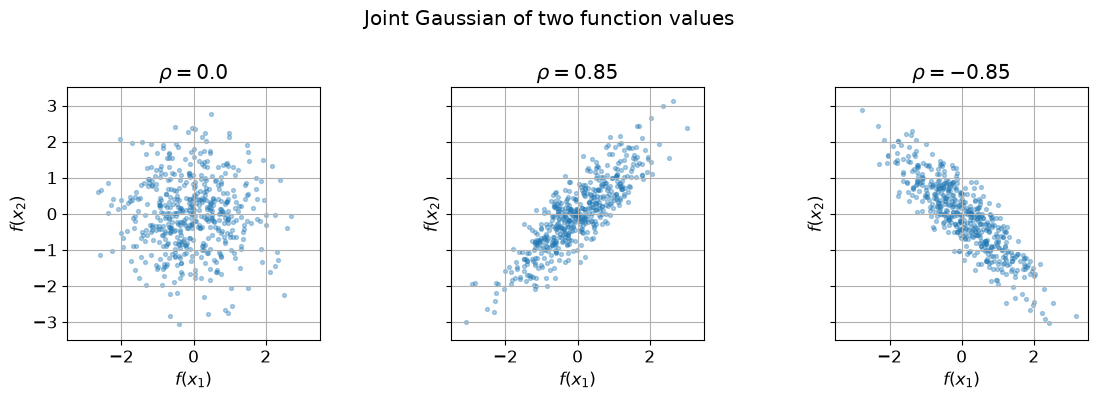

In [15]:
def sample_2d_gaussian(rho, n=500):
    cov = np.array([[1.0, rho], [rho, 1.0]])
    return np.random.multivariate_normal([0.0, 0.0], cov, size=n)


fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, rho in zip(axes, [0.0, 0.85, -0.85]):
    samples = sample_2d_gaussian(rho)
    ax.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.35)
    ax.set_title(rf"$\rho = {rho}$")
    ax.set_xlabel(r"$f(x_1)$")
    ax.set_ylabel(r"$f(x_2)$")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
fig.suptitle("Joint Gaussian of two function values", y=1.02)
plt.tight_layout()


Evaluating $f$ on a grid $x_1,\ldots,x_n$ is one $n$-dimensional Gaussian $\mathcal{N}(0, \tau^2 K)$. Sampling that Gaussian and plotting $(x_i, f_i)$ produces a random *curve*. Different kernels (different $\phi$) produce different families of curves.


## 2. Kernels

The Gram matrix $K = \Phi\Phi^\top$ is defined by a kernel $k(x, x') = \phi(x)^\top \phi(x')$. For the **stationary** kernels below we use unit kernels with $k(x,x) = 1$; the weight prior then supplies the scale $\tau^2$, so $\mathrm{Cov}\bigl(f(x), f(x')\bigr) = \tau^2 k(x, x')$. Lengthscale $\ell$ sets how quickly correlation decays with distance $r = |x - x'|$.

**Linear** and **polynomial** kernels instead depend on the inner product $u^\top v$. They are not stationary, and $k(x,x)$ grows with $\lVert x\rVert$.

**RBF / squared exponential** — infinitely smooth sample paths (infinite-dimensional $\phi$):

$$
k_{\mathrm{RBF}}(r) = \exp\Bigl(-\frac{r^2}{2\ell^2}\Bigr).
$$

**Matérn-5/2** — once continuously differentiable; a bit rougher than RBF:

$$
k_{5/2}(r) = \Bigl(1 + \frac{\sqrt{5}\, r}{\ell} + \frac{5 r^2}{3\ell^2}\Bigr) \exp\Bigl(-\frac{\sqrt{5}\, r}{\ell}\Bigr).
$$

**Laplacian / exponential** — continuous but not differentiable (Matérn-1/2; rougher still):

$$
k_{\mathrm{Lap}}(r) = \exp\Bigl(-\frac{r}{\ell}\Bigr).
$$

**Periodic** — repeating structure with period $p$:

$$
k_{\mathrm{per}}(r) = \exp\Bigl(-\frac{2\sin^2(\pi r / p)}{\ell^2}\Bigr).
$$

**Linear** — random lines through the origin in 1D ($\phi(x) = x$, so $f(x) = wx$):

$$
k_{\mathrm{lin}}(u, v) = u^\top v.
$$

**Polynomial** — random polynomials of degree $\gamma$ (we use $\gamma = 2$):

$$
k_{\mathrm{poly}}(u, v) = \bigl(1 + u^\top v\bigr)^\gamma.
$$


In [16]:
def rbf(x, xp, lengthscale=1.0):
    sqdist = (x[:, None] - xp[None, :]) ** 2
    return np.exp(-0.5 * sqdist / lengthscale**2)


def matern52(x, xp, lengthscale=1.0):
    r = np.abs(x[:, None] - xp[None, :]) / lengthscale
    s5 = np.sqrt(5.0)
    return (1.0 + s5 * r + 5.0 / 3.0 * r**2) * np.exp(-s5 * r)


def laplacian(x, xp, lengthscale=1.0):
    r = np.abs(x[:, None] - xp[None, :])
    return np.exp(-r / lengthscale)


def periodic(x, xp, lengthscale=1.0, period=2.0):
    dist = np.abs(x[:, None] - xp[None, :])
    sin2 = np.sin(np.pi * dist / period) ** 2
    return np.exp(-2.0 * sin2 / lengthscale**2)


def linear(x, xp):
    return x[:, None] * xp[None, :]


def polynomial(x, xp, gamma=2.0):
    return (1.0 + x[:, None] * xp[None, :]) ** gamma


def gram(kernel, x, xp=None, **kwargs):
    if xp is None:
        xp = x
    return kernel(x, xp, **kwargs)


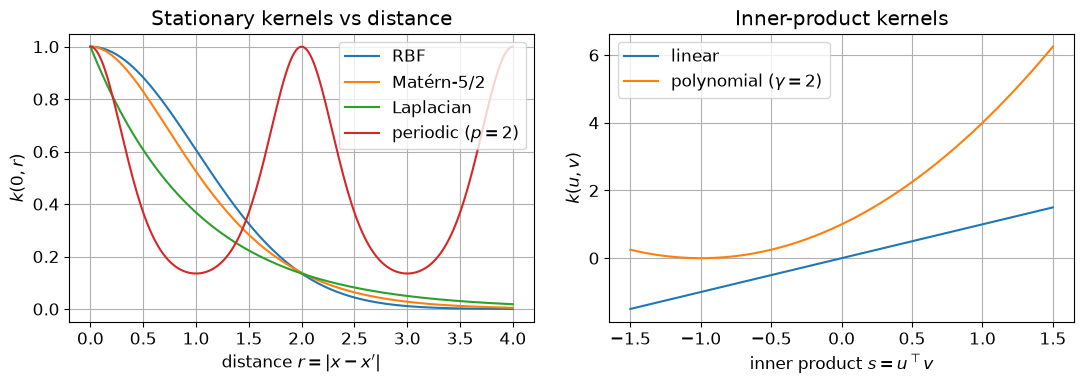

In [17]:
r = np.linspace(0.0, 4.0, 200)
x0 = np.array([0.0])
xr = r.copy()
s = np.linspace(-1.5, 1.5, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(r, rbf(x0, xr)[0], label="RBF")
ax.plot(r, matern52(x0, xr)[0], label="Matérn-5/2")
ax.plot(r, laplacian(x0, xr)[0], label="Laplacian")
ax.plot(r, periodic(x0, xr, period=2.0)[0], label="periodic ($p=2$)")
ax.set_xlabel(r"distance $r = |x - x'|$")
ax.set_ylabel(r"$k(0, r)$")
ax.set_title("Stationary kernels vs distance")
ax.legend()

ax = axes[1]
ax.plot(s, s, label="linear")
ax.plot(s, (1.0 + s) ** 2, label=r"polynomial ($\gamma=2$)")
ax.set_xlabel(r"inner product $s = u^\top v$")
ax.set_ylabel(r"$k(u, v)$")
ax.set_title("Inner-product kernels")
ax.legend()
plt.tight_layout()


The four stationary kernels start at $1$ when $r = 0$ (unit features: $\lVert\phi(x)\rVert^2 = 1$). RBF, Matérn, and Laplacian decay to zero; the periodic kernel *revives* every period $p$. Linear and polynomial are plotted against the inner product $s = u^\top v$: a line, and $(1+s)^\gamma$. The prior covariance of $f$ is $\tau^2$ times $K$ in every case.


## 3. Sampling from the prior

To draw function values $f \sim \mathcal{N}(0, \tau^2 K)$:

1. Form the Gram matrix $K_{ij} = k(x_i, x_j) = \phi(x_i)^\top \phi(x_j)$.
2. Factor $\tau^2 K + \varepsilon I = L L^\top$ (Cholesky). The jitter $\varepsilon$ keeps the matrix numerically positive definite.
3. Draw $z \sim \mathcal{N}(0, I)$ and set $f = Lz$.

This is the same as drawing $w \sim \mathcal{N}(0, \tau^2 I)$ and setting $f = \Phi w$, except we never instantiate $w$ or $\Phi$.


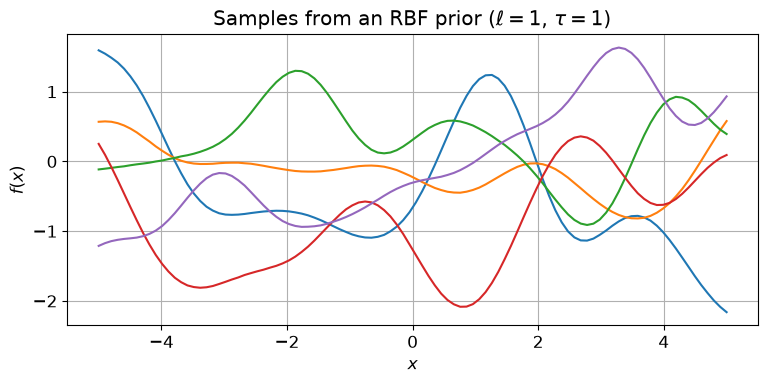

In [18]:
def sample_gp(cov, n_samples=5, z=None):
    n = cov.shape[0]
    L = np.linalg.cholesky(cov + JITTER * np.eye(n))
    if z is None:
        z = np.random.normal(size=(n, n_samples))
    return L @ z


x = np.linspace(-5.0, 5.0, 100)
tau = 1.0
K_rbf = gram(rbf, x, lengthscale=1.0)
prior_samples = sample_gp(tau**2 * K_rbf, n_samples=5)

fig, ax = plt.subplots()
ax.plot(x, prior_samples)
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title(r"Samples from an RBF prior ($\ell = 1$, $\tau = 1$)")
plt.tight_layout()


Each curve is one draw of $f = \Phi w$. They are smooth (RBF), wander about height zero with typical amplitude $\tau$, and vary on a lengthscale of about $1$.


## 4. Comparing kernels

Use the **same** Gaussian noise vector $z$ and the same grid so differences come from $\phi$ (the kernel), not from luck. RBF looks glassy-smooth, Matérn-5/2 a little less so, Laplacian is rough, and the periodic kernel repeats. Linear draws are straight lines through the origin; polynomial ($\gamma=2$) draws are quadratics.


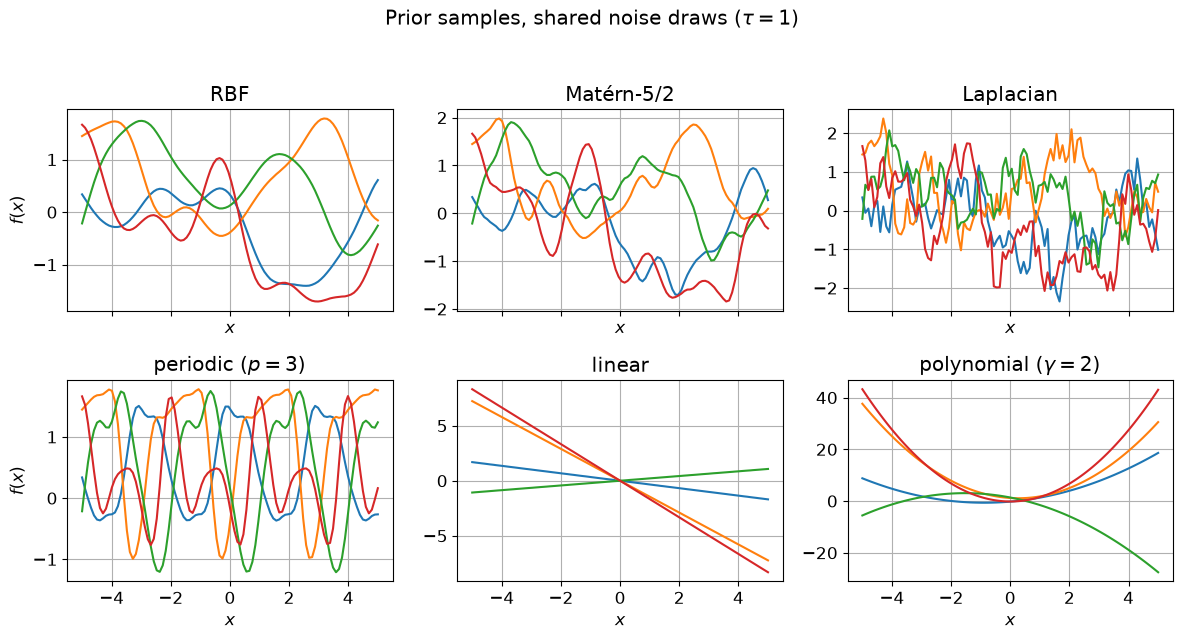

In [19]:
n_samples = 4
tau = 1.0
z = np.random.normal(size=(len(x), n_samples))

kernels = [
    ("RBF", rbf, {"lengthscale": 1.0}),
    ("Matérn-5/2", matern52, {"lengthscale": 1.0}),
    ("Laplacian", laplacian, {"lengthscale": 1.0}),
    ("periodic ($p=3$)", periodic, {"lengthscale": 1.0, "period": 3.0}),
    ("linear", linear, {}),
    (r"polynomial ($\gamma=2$)", polynomial, {"gamma": 2.0}),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.2), sharex=True)
axes = axes.ravel()
for ax, (name, kernel, kwargs) in zip(axes, kernels):
    K = gram(kernel, x, **kwargs)
    samples = sample_gp(tau**2 * K, z=z)
    ax.plot(x, samples)
    ax.set_title(name)
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
axes[3].set_ylabel("$f(x)$")
fig.suptitle(r"Prior samples, shared noise draws ($\tau = 1$)", y=1.03)
plt.tight_layout()


## 5. Posterior / GP regression

We observe $y = \Phi w + \sigma\varepsilon$. Predictions are the latent values $f_* = \Phi_* w$ at test inputs. Here $X_*$ is the raw test data and $\Phi_*$ has rows $\phi$ of those inputs. Rather than forming the posterior of $w$ (awkward when $d'$ is infinite), condition the joint Gaussian of $\begin{bmatrix} f_* \\ y \end{bmatrix}$.

The marginal of $y$ is the bottom-right block we already had:

$$
y \sim \mathcal{N}(0,\, \tau^2 K + \sigma^2 I).
$$

Let $K = k(X, X)$, $K_* = k(X, X_*)$, $K_{**} = k(X_*, X_*)$ be kernel matrices on the **raw** inputs (equal to $\Phi\Phi^\top$, $\Phi\Phi_*^\top$, $\Phi_*\Phi_*^\top$), and $K_y = \tau^2 K + \sigma^2 I$. Then

$$
\begin{aligned}
\mu_* &= \tau^2 K_*^\top K_y^{-1} y, \\
\Sigma_* &= \tau^2 K_{**} - \tau^2 K_*^\top K_y^{-1}\, \tau^2 K_*.
\end{aligned}
$$

We compute this with one Cholesky factor of $K_y$ rather than an explicit inverse. This is the same posterior you would get from $\mathcal{N}(w \mid y)$ followed by $f_* = \Phi_* w$.


In [20]:
def gp_posterior(x_train, y, x_test, kernel, tau, sigma, **kernel_kwargs):
    K = gram(kernel, x_train, **kernel_kwargs)
    K_s = gram(kernel, x_train, x_test, **kernel_kwargs)
    K_ss = gram(kernel, x_test, **kernel_kwargs)

    n = len(x_train)
    Ky = tau**2 * K + sigma**2 * np.eye(n)
    L = np.linalg.cholesky(Ky + JITTER * np.eye(n))

    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    mean = tau**2 * (K_s.T @ alpha)
    v = np.linalg.solve(L, tau * K_s)
    cov = tau**2 * K_ss - v.T @ v
    return mean, cov


def plot_gp(ax, x_test, mean, cov, x_train=None, y=None, n_samples=3, title=""):
    std = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    ax.fill_between(
        x_test, mean - 2 * std, mean + 2 * std,
        alpha=0.25, label=r"$\pm 2$ std",
    )
    ax.plot(x_test, mean, lw=2, label="posterior mean")
    if n_samples:
        samples = sample_gp(cov, n_samples=n_samples)
        ax.plot(x_test, mean[:, None] + samples, alpha=0.7, lw=1)
    if x_train is not None:
        ax.scatter(x_train, y, c="k", zorder=5, label="data")
    ax.set_xlabel("$x$")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=9)


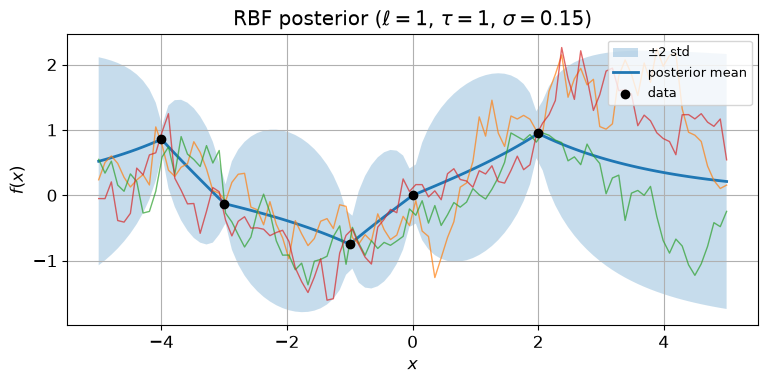

In [27]:
x_train = np.array([-4.0, -3.0, -1.0, 0.0, 2.0])
tau = 1.0
sigma = 0.05
y = np.sin(x_train) + sigma * np.random.normal(size=x_train.shape)
x_test = np.linspace(-5.0, 5.0, 100)

mean, cov = gp_posterior(
    x_train, y, x_test, laplacian, tau, sigma, lengthscale=2.0,
)

fig, ax = plt.subplots()
plot_gp(
    ax, x_test, mean, cov, x_train, y,
    title=r"RBF posterior ($\ell=1$, $\tau=1$, $\sigma=0.15$)",
)
ax.set_ylabel("$f(x)$")
plt.tight_layout()


Near the data the band shrinks and the mean interpolates (up to noise). Far from the data the mean returns to $0$ and the band returns to the prior width $\tau$. Posterior samples are prior-like curves that have been *tied* to the observations.


## 6. Lengthscale, noise, and $\tau$

Same data, different $\ell$ or $\sigma$ (with $\tau = 1$ fixed). Too-small lengthscale: wiggly mean, overconfident near points, uncertain everywhere else. Too-large lengthscale: almost linear, ignores local structure. Small $\sigma$: the mean threads the points. Large $\sigma$: the data are treated as unreliable, so the fit stays closer to the prior on $w$.


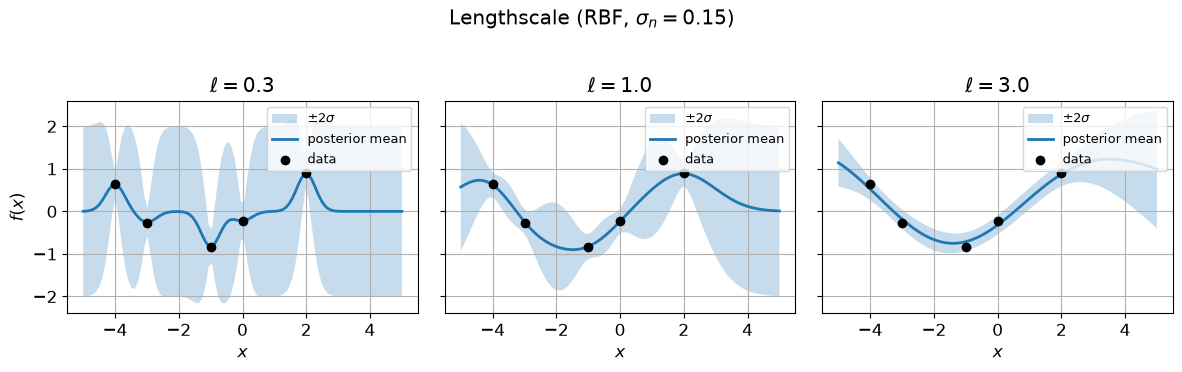

In [9]:
lengthscales = [0.3, 1.0, 3.0]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
for ax, ell in zip(axes, lengthscales):
    mean, cov = gp_posterior(
        x_train, y, x_test, rbf, tau, sigma, lengthscale=ell,
    )
    plot_gp(ax, x_test, mean, cov, x_train, y, n_samples=0, title=rf"$\ell = {ell}$")
axes[0].set_ylabel("$f(x)$")
fig.suptitle(r"Lengthscale (RBF, $\tau = 1$, $\sigma = 0.15$)", y=1.03)
plt.tight_layout()


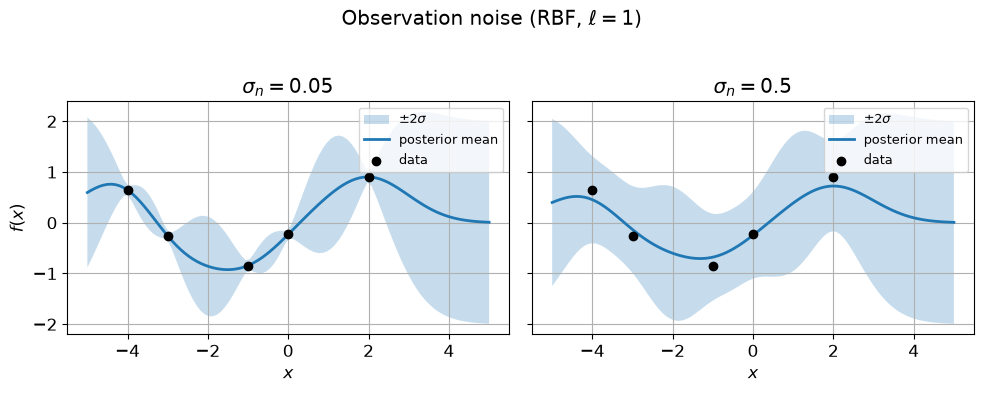

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True, sharey=True)
for ax, sn in zip(axes, [0.05, 0.5]):
    mean, cov = gp_posterior(
        x_train, y, x_test, rbf, tau, sn, lengthscale=1.0,
    )
    plot_gp(ax, x_test, mean, cov, x_train, y, n_samples=0, title=rf"$\sigma = {sn}$")
axes[0].set_ylabel("$f(x)$")
fig.suptitle(r"Observation noise (RBF, $\ell = 1$, $\tau = 1$)", y=1.03)
plt.tight_layout()


The covariance of $y$ is $\tau^2 K + \sigma^2 I$. Rearranging, the posterior **mean** depends on $\tau$ and $\sigma$ only through the ratio $\sigma/\tau$: doubling $\tau$ (a wider prior on $w$) has the same effect on the mean as halving $\sigma$. The posterior uncertainty still scales with $\tau$, so the two are not identical — but they push the fit in the same direction.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
settings = [
    (1.0, 0.15, r"baseline $\tau=1$, $\sigma=0.15$"),
    (2.0, 0.15, r"double $\tau$"),
    (1.0, 0.075, r"half $\sigma$"),
]
for ax, (tau_i, sigma_i, title) in zip(axes, settings):
    mean, cov = gp_posterior(
        x_train, y, x_test, rbf, tau_i, sigma_i, lengthscale=1.0,
    )
    plot_gp(ax, x_test, mean, cov, x_train, y, n_samples=0, title=title)
axes[0].set_ylabel("$f(x)$")
fig.suptitle(r"Scaling $\tau$ vs inversely scaling $\sigma$", y=1.03)
plt.tight_layout()

## Takeaways

- A GP is Bayesian linear regression with features $\phi$, possibly infinite-dimensional. Raw data $X \in \mathbb{R}^{n \times d}$ produce $\Phi \in \mathbb{R}^{n \times d'}$. Weights $w \sim \mathcal{N}(0, \tau^2 I)$ and $y = \Phi w + \sigma\varepsilon$.
- The joint $\begin{bmatrix} w \\ y \end{bmatrix}$ is Gaussian with covariance $\begin{bmatrix} \tau^2 I & \tau^2 \Phi^\top \\ \tau^2 \Phi & \tau^2 K + \sigma^2 I \end{bmatrix}$, where $K = \Phi\Phi^\top$.
- With kernels we never form $w$ or $\Phi$; we evaluate $k$ on the raw $X$ and condition $y$ to predict $f_*$.
- Lengthscale $\ell$ controls how far a point's influence reaches. Noise $\sigma$ and weight scale $\tau$ control how tightly we fit; they enter as the ratio $\sigma/\tau$ in the posterior mean.

We did not fit $\ell$, $\tau$, or $\sigma$ here. The usual next step is maximising the log marginal likelihood $\log p(y \mid X, \ell, \tau, \sigma)$, which we leave for another class.
